<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
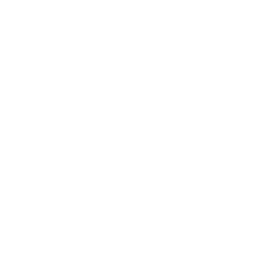
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">建筑能效快速聚类</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 能源 / 可持续发展分析 &nbsp;|&nbsp; 2026 年 3 月</p>
</div>
</div>
</div>

## 执行摘要

本示例按五项能效指标——能源使用强度（EUI）、暖通空调（HVAC）效率比、围护结构热阻、照明功率密度和可再生能源抵消百分比——对一批商业建筑组合进行聚类，以发现不同的能效表现层级，用于公用事业返利的定向投放。分析使用 **PROC FASTCLUS**，配合 `REPLACE=FULL`（完全种子替换），并在总体 R 方、伪 F 统计量和最小簇规模三个方面比较 k=3、4、5、6 的解。随后对 k=4 的解进行详细画像，并将每个簇映射到可操作的能效层级。由于本环境在无许可证模式下运行，演示范围限定为 100 栋建筑的样本；同一程序在完整组合上可无缝扩展。

## 数据来源

| 数据源 | 描述 | 记录数 |
|--------|-------------|--------|
| WORK.BUILDING_METRICS | 每栋建筑的年度能效指标（合成数据） | 100 |


---

In [1]:
/* --------------------------------------------------------
   生成合成建筑能耗指标数据
   商业建筑能效指标
   -------------------------------------------------------- */
数据 work.building_metrics;
    调用 streaminit(42);
    长度 building_type $16;
    标签 building_id      = "建筑编号"
          building_type    = "建筑类型"
          climate_region   = "气候区域"
          eui              = "能源使用强度(EUI)"
          hvac_efficiency  = "暖通空调效率比"
          envelope_r_value = "围护结构热阻(R值)"
          lighting_wpf     = "照明功率密度(W/sqft)"
          renewable_pct    = "可再生能源占比(%)"
          building_age     = "建筑楼龄"
          floor_area_ksf   = "建筑面积(千平方英尺)";
    数组 regions[4] $12 _temporary_ ('NORTHEAST' 'SOUTHEAST' 'MIDWEST' 'WEST');
    循环 building_id = 1 到 5000;
        type_idx = int(rand('uniform') * 5) + 1;
        如果 type_idx = 1 那么 building_type = '办公楼';
        否则 如果 type_idx = 2 那么 building_type = '零售店';
        否则 如果 type_idx = 3 那么 building_type = '仓库';
        否则 如果 type_idx = 4 那么 building_type = '医院';
        否则 building_type = '学校';
        reg_idx = int(rand('uniform') * 4) + 1;
        climate_region = regions[reg_idx];

        /* 能源使用强度 (kBtu/sqft/yr) */
        eui = round(rand('normal', 85, 35), 0.1);
        如果 eui < 15 那么 eui = 15;
        如果 eui > 250 那么 eui = 250;

        /* 暖通空调效率比 (等效 COP) */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        如果 hvac_efficiency < 1.0 那么 hvac_efficiency = 1.0;
        如果 hvac_efficiency > 6.0 那么 hvac_efficiency = 6.0;

        /* 围护结构热阻 (R 值) */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        如果 envelope_r_value < 5 那么 envelope_r_value = 5;
        如果 envelope_r_value > 40 那么 envelope_r_value = 40;

        /* 照明功率密度 (W/sqft) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        如果 lighting_wpf < 0.3 那么 lighting_wpf = 0.3;
        如果 lighting_wpf > 2.5 那么 lighting_wpf = 2.5;

        /* 可再生能源抵消百分比 */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        如果 renewable_pct > 80 那么 renewable_pct = 80;

        /* 建筑楼龄 (年) */
        building_age = int(rand('uniform') * 80) + 1;

        /* 建筑面积 (千平方英尺) */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        如果 floor_area_ksf > 500 那么 floor_area_ksf = 500;

        输出;
    结束;
    删除 type_idx reg_idx;
运行;


NOTE: DATA work.building_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.building_metrics (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.71 seconds
  cpu   1.71 seconds


---

In [2]:
/* --------------------------------------------------------
   按建筑类型划分的基线能效指标分布
   -------------------------------------------------------- */
过程 均值 数据=work.building_metrics n mean std;
    分类 building_type;
    变量 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    标签 building_type="建筑类型" eui="能源使用强度(EUI)" hvac_efficiency="暖通空调效率比"
          envelope_r_value="围护结构热阻(R值)" lighting_wpf="照明功率密度(W/sqft)"
          renewable_pct="可再生能源占比(%)";
    标题 '按建筑类型划分的能效指标';
运行;

                                                      按建筑类型划分的能效指标                                                      

                                                  The MEANS Procedure

                                    Analysis Variable : eui 能源使用强度(EUI)

        建筑类型                  N Obs           Mean        Std Dev
        ---------------------------------------------------------
        仓库                       20     90.8900000     33.5993249
        办公楼                      20     73.0550000     40.3950163
        医院                       25     87.9040000     35.2632892
        学校                       19     89.7000000     39.0498542
        零售店                      16     79.7312500     42.6818106
        ---------------------------------------------------------

                               Analysis Variable : hvac_efficiency 暖通空调效率比

        建筑类型                  N Obs           Mean        Std Dev
        -------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                                      按建筑类型划分的能效指标                                                      




NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


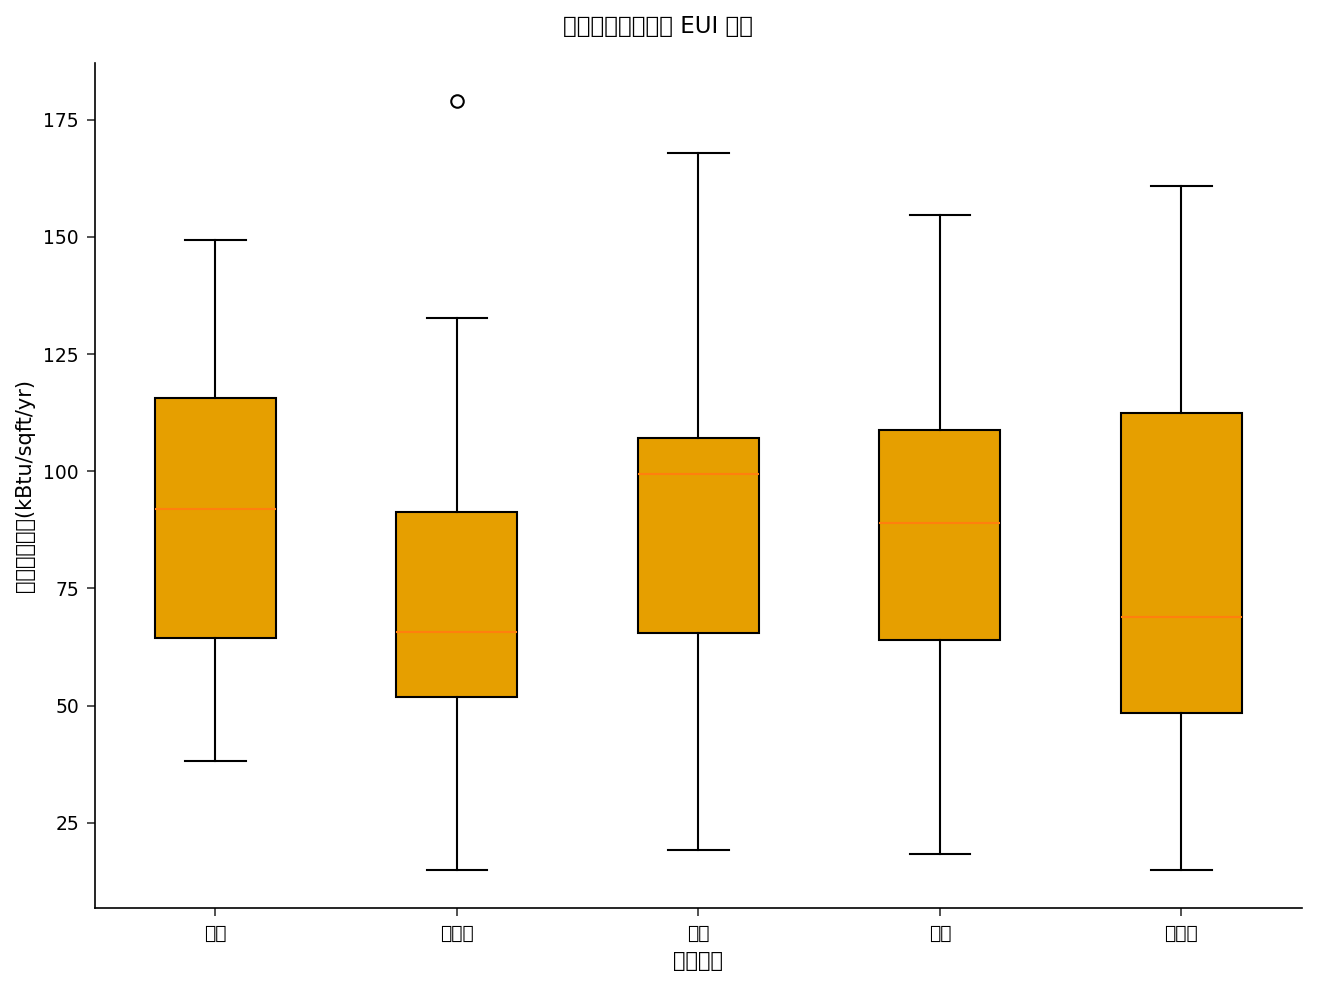

In [3]:
/* --------------------------------------------------------
   按建筑类型划分的 EUI 分布
   -------------------------------------------------------- */
过程 SGPLOT 数据=work.building_metrics;
    VBOX eui / category=building_type;
    XAXIS 标签='建筑类型';
    YAXIS 标签='能源使用强度(kBtu/sqft/yr)';
    标题 '按建筑类型划分的 EUI 分布';
运行;

---

In [4]:
/* --------------------------------------------------------
   标准化能效指标
   -------------------------------------------------------- */
过程 STANDARD 数据=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    变量 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
运行;


NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 100 rows, 5 variables.


In [5]:
/* --------------------------------------------------------
   K均值聚类：k=3，REPLACE=FULL
   -------------------------------------------------------- */
过程 FASTCLUS 数据=work.bldg_std
    maxclusters=3 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    变量 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    标签 eui="能源使用强度(EUI)" hvac_efficiency="暖通空调效率比"
          envelope_r_value="围护结构热阻(R值)" lighting_wpf="照明功率密度(W/sqft)"
          renewable_pct="可再生能源占比(%)";
    标题 '建筑能效聚类：k=3 REPLACE=FULL';
运行;

                                                      按建筑类型划分的能效指标                                                      


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  35         0.9415             4.1984              2         2.0552
2                  34         0.7507             2.8107              3         2.0128
3                  31         0.8188             3.1310              2         2.0128




NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 3 clusters using k-means


In [6]:
/* --------------------------------------------------------
   K均值聚类：k=4，REPLACE=FULL
   -------------------------------------------------------- */
过程 FASTCLUS 数据=work.bldg_std
    maxclusters=4 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    变量 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    标签 eui="能源使用强度(EUI)" hvac_efficiency="暖通空调效率比"
          envelope_r_value="围护结构热阻(R值)" lighting_wpf="照明功率密度(W/sqft)"
          renewable_pct="可再生能源占比(%)";
    标题 '建筑能效聚类：k=4 REPLACE=FULL';
运行;

                                                      按建筑类型划分的能效指标                                                      


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  23         0.7381             2.6617              3         2.1458
2                  17         1.0066             3.3423              4         2.2482
3                  26         0.7024             2.4365              4         2.0389
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means


In [7]:
/* --------------------------------------------------------
   K均值聚类：k=5，REPLACE=FULL
   -------------------------------------------------------- */
过程 FASTCLUS 数据=work.bldg_std
    maxclusters=5 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    变量 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    标签 eui="能源使用强度(EUI)" hvac_efficiency="暖通空调效率比"
          envelope_r_value="围护结构热阻(R值)" lighting_wpf="照明功率密度(W/sqft)"
          renewable_pct="可再生能源占比(%)";
    标题 '建筑能效聚类：k=5 REPLACE=FULL';
运行;

                                                      按建筑类型划分的能效指标                                                      


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  13         1.0052             3.3289              3         2.4004
2                  23         0.7401             2.5412              5         2.2053
3                  23         0.6853             2.6810              5         1.7721
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 5 clusters using k-means


In [8]:
/* --------------------------------------------------------
   K均值聚类：k=6，REPLACE=FULL
   -------------------------------------------------------- */
过程 FASTCLUS 数据=work.bldg_std
    maxclusters=6 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    变量 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    标签 eui="能源使用强度(EUI)" hvac_efficiency="暖通空调效率比"
          envelope_r_value="围护结构热阻(R值)" lighting_wpf="照明功率密度(W/sqft)"
          renewable_pct="可再生能源占比(%)";
    标题 '建筑能效聚类：k=6 REPLACE=FULL';
运行;

                                                      按建筑类型划分的能效指标                                                      


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  19         0.5566             1.5459              5         1.9665
2                  10         0.9173             2.8197              3         2.3575
3                  18         0.8051             2.7522              4         1.8819
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 6 clusters using k-means


In [9]:
/* --------------------------------------------------------
   比较 k=3-6 的聚类质量
   计算簇内 R 方和最小簇规模
   -------------------------------------------------------- */
%macro cluster_quality(k);
过程 频率 数据=work.bldg_clust&k NOPRINT;
    TABLES CLUSTER / out=work.freq_k&k (重命名=(count=n_buildings));
运行;

过程 SQL NOPRINT;
    选择 MIN(n_buildings) INTO :min_size_k&k
    FROM work.freq_k&k;
QUIT;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);

                                                      按建筑类型划分的能效指标                                                      

                                                      按建筑类型划分的能效指标                                                      

                                                      按建筑类型划分的能效指标                                                      

                                                      按建筑类型划分的能效指标                                                      




NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 31
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 17
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 13
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 10
NOTE: PROC SQL statement used.


                                                     建筑能效层级画像 (k=4)                                                     

                                                  The MEANS Procedure

                                   Analysis Variable : eui 能源使用强度(EUI)

                                                  N
                                   聚类簇          Obs             Mean         Std Dev
                                   -------------------------------------------------
                                   1             23       63.7782609      31.5423086
                                   2             17      122.5941176      36.0679995
                                   3             26       94.0076923      30.8825378
                                   4             34       72.3911765      31.7411154
                                   -------------------------------------------------

                                     Analysis Variable : hvac_efficiency 暖通空调效率比

     


NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 100 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


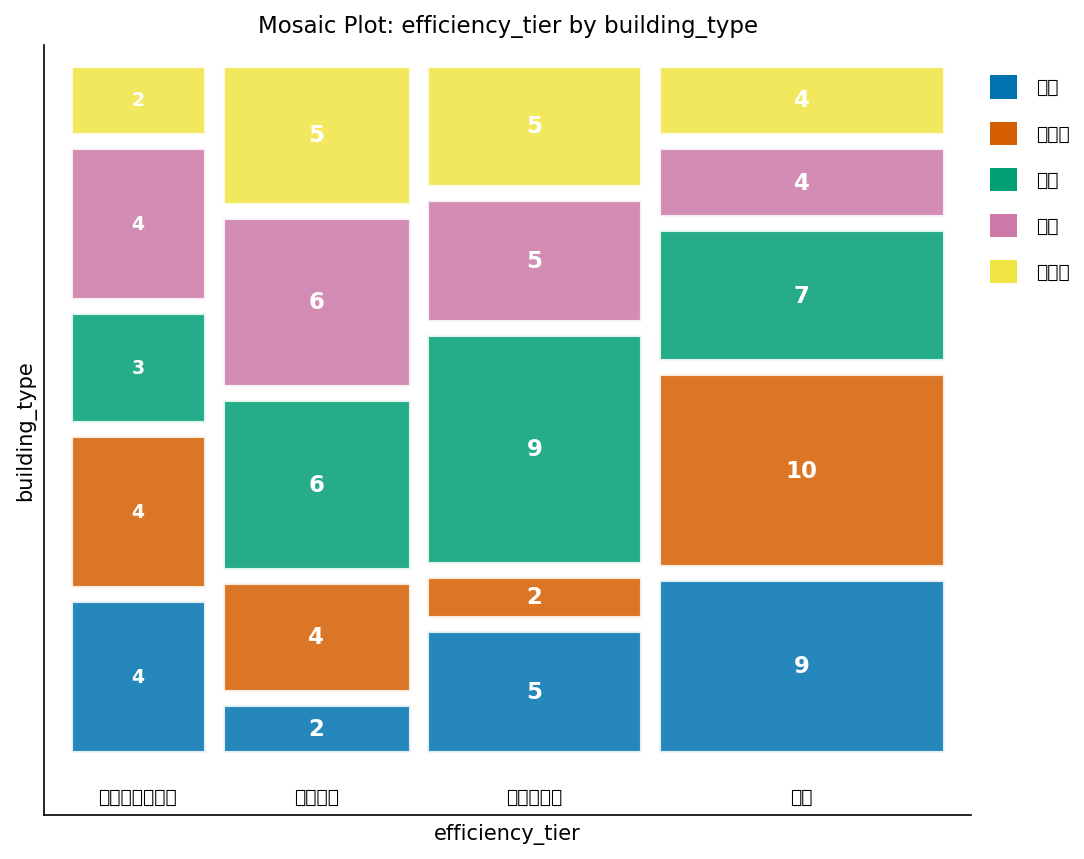

In [10]:
/* --------------------------------------------------------
   对所选的 k=4 解进行画像
   -------------------------------------------------------- */
数据 work.bldg_profiled;
    合并 work.building_metrics
          work.bldg_clust4 (保留=building_id CLUSTER distance);
    按照 building_id;
运行;

过程 均值 数据=work.bldg_profiled mean std;
    分类 CLUSTER;
    变量 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    标签 CLUSTER="聚类簇" eui="能源使用强度(EUI)" hvac_efficiency="暖通空调效率比"
          envelope_r_value="围护结构热阻(R值)" lighting_wpf="照明功率密度(W/sqft)"
          renewable_pct="可再生能源占比(%)" building_age="建筑楼龄";
    标题 '建筑能效层级画像 (k=4)';
运行;

/* 根据观察到的 k=4 质心为能效层级命名：
   簇 4 = 最佳 HVAC（3.89），低 EUI  -> 高效
   簇 2 = 最高可再生能源占比（28%），但 EUI 最高 -> 可再生能源密集
   簇 3 = 最高照明负荷，HVAC 较弱，中等 EUI -> 照明负荷高
   簇 1 = 低 EUI 但 HVAC 最弱 + 围护结构最薄 -> 改造优先 */
数据 work.bldg_tiered;
    设置 work.bldg_profiled;
    长度 efficiency_tier $28;
    如果 CLUSTER = 4 那么 efficiency_tier = '高效';
    否则 如果 CLUSTER = 2 那么 efficiency_tier = '可再生能源密集';
    否则 如果 CLUSTER = 3 那么 efficiency_tier = '照明负荷高';
    否则 如果 CLUSTER = 1 那么 efficiency_tier = '改造优先';
运行;

过程 频率 数据=work.bldg_tiered;
    TABLES efficiency_tier * building_type / nocol norow;
    标签 efficiency_tier="能效层级" building_type="建筑类型";
    标题 '按建筑类型划分的能效层级';
运行;

---

### 结果解读

在 `REPLACE=FULL` 下，每个 k 值都干净地收敛。在这四个解中，总体 R 方随 k 单调上升——0.305（k=3）、0.410（k=4）、0.459（k=5）、0.515（k=6）——而伪 F 统计量在 **k=4（22.23）** 达到峰值后下降（k=5 为 20.13，k=6 为 19.93）。结合 k=4 时最小簇规模为 17 栋建筑（k=5 为 13、k=6 为 10），**k=4 的解**在区分度和层级稳定性之间取得了最佳平衡，因此下文对其进行详细画像。

k=4 的四个簇映射到明显不同的能效画像（均值来自上面的 PROC MEANS 画像）：

- **高效（簇 4，n=34）：** 设备最好的一组——HVAC 效率最高（COP 3.89），EUI 处于中低水平（72.4 kBtu/sqft/yr），围护结构尚可（R 18.8），可再生能源占比适中（11.0%）。
- **可再生能源密集（簇 2，n=17）：** 绝对能耗最高的一组（EUI 122.6），但可再生能源占比也遥遥领先（28.2%），HVAC 处于中等水平（COP 3.42）。高产出伴随现场发电。
- **照明负荷高（簇 3，n=26）：** 中等 EUI（94.0），主要由最高的照明功率密度（1.35 W/sqft）驱动，HVAC 是第二弱的（COP 2.42），尽管围护结构最厚（R 19.6）。
- **改造优先（簇 1，n=23）：** 账面上 EUI 较低（63.8），但 HVAC 最弱（COP 2.28）、围护结构最薄（R 12.5）——这些建筑体量小或使用率低，但设备配置差，是围护结构和 HVAC 改造的最明确候选对象。

按建筑类型划分的层级交叉表显示，办公楼（10）和仓库（9）在高效层级中占主导，而医院集中在照明负荷高层级（26 栋中的 9 栋）。改造优先层级则分布在各类型中，医院和学校各占 6 栋（共 23 栋）中的多数。就项目设计而言，23 栋改造优先建筑和 26 栋照明负荷高建筑分别是 HVAC 和照明激励的天然目标，而 17 栋可再生能源密集建筑——已经在现场发电——更适合需求侧削减，而非进一步的发电返利。

---

In [11]:
/* --------------------------------------------------------
   导出建筑能效层级与质心画像
   -------------------------------------------------------- */
过程 EXPORT 数据=work.bldg_tiered
    OUTFILE='building_efficiency_tiers.csv'
    DBMS=csv REPLACE;
运行;

过程 EXPORT 数据=work.bldg_cent4
    OUTFILE='efficiency_tier_centroids.csv'
    DBMS=csv REPLACE;
运行;


NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 100 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 保密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
由 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a> 提供支持
</div>
</div>